In [6]:
import importlib
import sys
from pathlib import Path

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent  # Up to mjosa_code root
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code (NEW structure)
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)
from utils.uhi.georef import *

In [ ]:
stop

In [7]:
# ========== TRANSECT 057 (DEFAULT) ==========
# Load transect 057
transect = load_transect(config.TRANSECT_057_OUTPUT)
transect.list_files()

# Select ALL files (the ones you want to be available for processing)
# Note: All files will be checked, and only unprocessed ones will be processed
cube = transect.select_files(
    [
        # "rad_uhi_20241029_115057_1",
        # "rad_uhi_20241029_115057_2",
        # "rad_uhi_20241029_115057_3",
        # "rad_uhi_20241029_115057_4",
        "rad_uhi_20241029_115057_5",
    ]
)
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
Spectral bands: 210
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📊 Spectral configuration:
   Wavelength range: 380.9 -

In [8]:
cube.apply_illumination_correction_v3()

🔄 Using V3 algorithm (rolling window only, strategy=memory)
✅ All files already have illumination correction (window=500, strength=1.0)
   Loading from disk...
📂 Loading saved illumination correction from 1 files...


   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[2.2304249e+00, 1.6764377e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.0077596e+00, 0.0000000e+00],
        [7.4757171e+00, 8.5974735e-01, 0.0000000e+00, ...,
         0.0000000e+00, 3.0958059e+00, 0.0000000e+00],
        [1.8294926e+00, 2.3438740e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.1090145e+00, 0.0000000e+00],
        ...,
        [1.7213115e+00, 1.4317783e+00, 0.0000000e+00, ...,
         1.0000000e+00, 2.3279436e-02, 3.7040919e-01],
        [5.8812752e+00, 2.0123754e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.4956644e+00, 0.0000000e+00],
        [2.3867478e+00, 1.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.5736811e+01, 4.5105180e-01]],

       [[2.2304249e+00, 7.7452070e-01, 3.9940205e+00, ...,
         0.0000000e+00, 0.0000000e+00, 9.6023534e-05],
        [1.7471981e+00, 0.0000000e+00, 1.2654871e+00, ...,
         0.0000000e+00, 8.5029960e-01, 6.3767982e-01],
        [1.9216584e+00, 0.0000000e+00, 3.0771544e+00, ...,
         0.000

In [ ]:
# # Test: Check if data_corrected exists after v3
# print("Before v3:")
# print(f"  hasattr(cube, 'data_corrected'): {hasattr(cube, 'data_corrected')}")
# if hasattr(cube, "data_corrected"):
#     print(f"  cube.data_corrected is None: {cube.data_corrected is None}")

# result = cube.apply_illumination_correction_v3()

# print("\nAfter v3:")
# print(f"  hasattr(cube, 'data_corrected'): {hasattr(cube, 'data_corrected')}")
# if hasattr(cube, "data_corrected"):
#     print(f"  cube.data_corrected is None: {cube.data_corrected is None}")
#     if cube.data_corrected is not None:
#         print(f"  cube.data_corrected.shape: {cube.data_corrected.shape}")
# print(f"  Return value is None: {result is None}")
# if result is not None:
#     print(f"  Return value shape: {result.shape}")

In [9]:
cube.adjust_uhi_alignment(dx=-0.05, dy=-3.0)

✅ UHI alignment adjusted:
   dx (East):  -0.050 m
   dy (North): -3.000 m

💡 This will be applied in plot_georef() with coordinate_system='NED'


In [5]:
print_processing_statistics(track_start=8637, track_end=9709)

PROCESSING STATISTICS

📅 SESSION INFO
  Started: 2025-10-11 16:35:10
  Finished: 2025-10-11 16:44:08
  Processing duration: 8m 57s

⚙️  CONFIGURATION
  Navigation CSV: nav_data_merged.csv
  MBES GeoTIFF: geotiff_2.tif
  Output folder: output
  Max ray length: 100.0 m
  Failure threshold: 50.0%

🧭 NAVIGATION DATA
  Total records: 232,670 (navigation data points in CSV)
  Start time: 1730196822.84 (2024-10-29 10:22:10 UTC)
  End time: 1730207699.44 (2024-10-29 13:23:27 UTC)
  Duration: 10876.6 s (181.3 min)

🗺️  MBES MESH
  Vertices: 7,390,592
  Faces: 7,383,936
  Bounds (X): [592829.45, 592857.59] m
  Bounds (Y): [6741790.71, 6741895.67] m
  Bounds (Z): [-136.01, -110.83] m

📷 CAMERA CALIBRATION
  Focal length: 930.63 px
  Principal point: 484.75 px
  Image width: 968 px

📊 COMBINED TRANSECT STATISTICS (All H5 files together)

  Files processed: 6 total
    ✅ Successful: 6
    ❌ Failed: 0

  HSI Data:
    Total frames: 10,586
    Total rays: 10,247,248
    Successful hits: 10,094,582
  

{'processing_session': {'start_time': '2025-10-11 16:35:10',
  'end_time': '2025-10-11 16:44:08',
  'duration_sec': 537.849462,
  'duration_human': '8m 57s'},
 'configuration': {'nav_csv': 'E:\\mjosa_new\\navigation_data\\nav_data_merged.csv',
  'mbes_geotiff': 'E:\\mjosa_new\\DTM\\geotiff_2.tif',
  'camera_calib_xml': 'E:\\mjosa_new_oct_2025\\anxillary_data\\HSI_2_body.xml',
  'output_folder': 'E:\\mjosa_new_oct_2025\\use_gref4hsi\\057_final\\output',
  'max_ray_length_m': 100.0,
  'early_failure_threshold_pct': 50.0,
  'epsg_mbes': 32632,
  'sensor_translation': [0.0, -2.5, 0.0],
  'sensor_rotation': [[0.0, 1.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, -1.0]]},
 'navigation_data': {'total_records': 232670,
  'time_range': {'start': 1730196822.8426645,
   'end': 1730207699.4423833,
   'duration_sec': 10876.599718809128}},
 'mbes_mesh': {'n_vertices': 7390592,
  'n_faces': 7383936,
  'bounds': {'x_min': 592829.45,
   'x_max': 592857.59,
   'y_min': 6741790.71,
   'y_max': 6741895.67,
   'z_mi

# one cell to get depth for 028

In [ ]:
import importlib
import sys
from pathlib import Path

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent  # Up to mjosa_code root
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code (NEW structure)
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)
from utils.uhi.georef import *

# ========== TRANSECT 028 ==========
# Load transect 028
transect = load_transect(config.TRANSECT_028_OUTPUT)
transect.list_files()

# Select file from transect 028
cube = transect.select_files(["rad_uhi_20241029_125028_1"])
cube = transect.select_files(["rad_uhi_20241029_125028_2"])
cube = transect.select_files(["rad_uhi_20241029_125028_3"])
cube = transect.select_files(["rad_uhi_20241029_125028_4"])
cube = transect.select_files(["rad_uhi_20241029_125028_5"])

# Get statistics for transect 028 (explicitly specify the path)
stats_path_028 = config.TRANSECT_028_OUTPUT / "processing_statistics.json"
print_processing_statistics(
    stats_file_path=stats_path_028, track_start=None, track_end=None
)

In [ ]:
cube.plot_georef(
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    use_corrected=False,
    apply_alignment_shift=True,
    # contrast_stretch=2,  # Linear stretch at 2nd-98th percentiles for enhanced contrast
    figsize=(50, 20),
    # rotation_deg=1,  # Rotation angle in degrees
    add_scale_bar=True,  # Enable scale bar
    scale_bar_length_m=1.0,  # User-specified scale bar length in meters
    scale_bar_position="lower left",  # Position
    scale_bar_color="black",  # Color
    scale_bar_fontsize=20,  # Font size
    scale_bar_linewidth=2,
    add_north_arrow=True,  # Enable north arrow
    north_arrow_position="upper right",  # Position
    north_arrow_size=0.1,  # Size relative to plot
    north_arrow_color="black",  #
    north_arrow_head_size=20,
    north_arrow_linewidth=2,
)

🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates


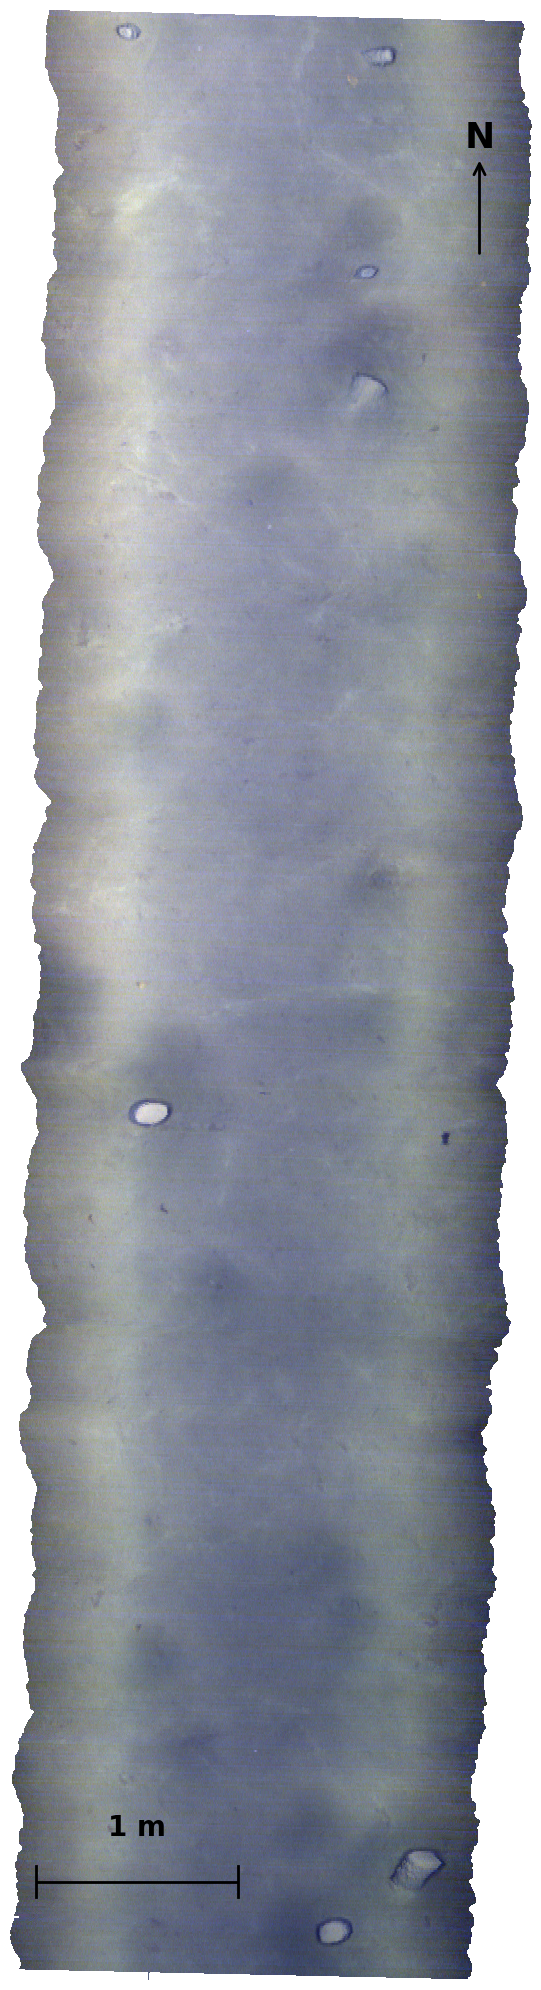

In [10]:
# Publication-ready mosaic - Save to PDF with no axis borders
from pathlib import Path

# Setup output directory
output_dir = Path.cwd().parent / "images_for_publication"
output_dir.mkdir(exist_ok=True)

# Choose filename based on data type
# Options: "057_mosaic_radiance.pdf", "057_mosaic_corrected.pdf", etc.
output_file = output_dir / "057_mosaic_radiance.pdf"

cube.plot_georef(
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    use_corrected=False,
    apply_alignment_shift=True,
    figsize=(50, 20),
    add_scale_bar=True,
    scale_bar_length_m=1.0,
    scale_bar_position="lower left",
    scale_bar_color="black",
    scale_bar_fontsize=20,
    scale_bar_linewidth=2,
    add_north_arrow=True,
    north_arrow_position="upper right",
    north_arrow_size=0.1,
    north_arrow_color="black",
    north_arrow_head_size=20,
    north_arrow_linewidth=2,
    hide_axes=True,
    save_file=str(output_file),
    save_dpi=300,
)

🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates


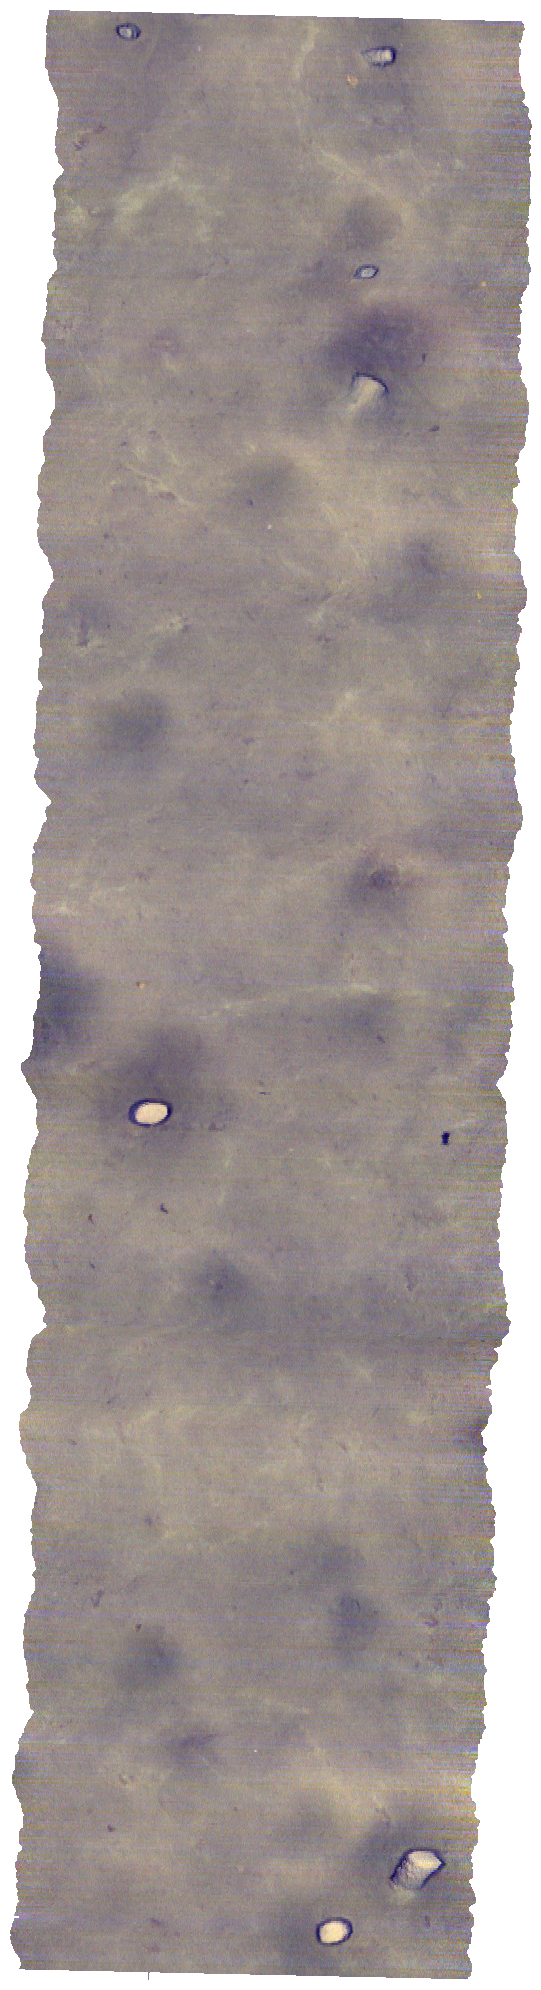

In [11]:
# Publication-ready mosaic - Save to PDF with no axis borders
from pathlib import Path

# Setup output directory
output_dir = Path.cwd().parent / "images_for_publication"
output_dir.mkdir(exist_ok=True)

# Choose filename based on data type
# Options: "057_mosaic_radiance.pdf", "057_mosaic_corrected.pdf", etc.
output_file = output_dir / "057_mosaic_psuedo.pdf"

cube.plot_georef(
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    use_corrected=True,
    apply_alignment_shift=True,
    figsize=(50, 20),
    add_scale_bar=False,
    scale_bar_length_m=1.0,
    scale_bar_position="lower left",
    scale_bar_color="black",
    scale_bar_fontsize=20,
    scale_bar_linewidth=2,
    add_north_arrow=False,
    north_arrow_position="upper right",
    north_arrow_size=0.1,
    north_arrow_color="black",
    north_arrow_head_size=20,
    north_arrow_linewidth=2,
    hide_axes=True,
    save_file=str(output_file),
    save_dpi=300,
)

In [ ]:
cube.plot_georef(
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    use_corrected=True,
    apply_alignment_shift=True,
    # contrast_stretch=2,  # Linear stretch at 2nd-98th percentiles for enhanced contrast
)

In [ ]:
cube.plot_georef(
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    use_corrected=True,
    apply_alignment_shift=True,
    contrast_stretch=2,  # Linear stretch at 2nd-98th percentiles for enhanced contrast
    figsize=(50, 20),
    # rotation_deg=1,  # Rotation angle in degrees
    # add_scale_bar=True,  # Enable scale bar
    # scale_bar_length_m=1.0,  # User-specified scale bar length in meters
    # scale_bar_position="lower left",  # Position
    # scale_bar_color="black",  # Color
    # scale_bar_fontsize=20,  # Font size
    # scale_bar_linewidth=2,
    # add_north_arrow=True,  # Enable north arrow
    # north_arrow_position="upper right",  # Position
    # north_arrow_size=0.1,  # Size relative to plot
    # north_arrow_color="black",  #
    # north_arrow_head_size=20,
    # north_arrow_linewidth=2,
)

In [ ]:
cube.plot_spectrum(
    use_corrected=False,
    wavelength_range=(490, 700),
    track_index=config.UHI_TRACK_RANGE[0] + 100,
    slit_index=300,
)


cube.plot_spectrum(
    use_corrected=False,
    wavelength_range=(490, 700),
    track_index=config.UHI_TRACK_RANGE[0] + 100,
    slit_index=300,
    smoothing_method="gaussian",
    wavelength_smoothing=2,  # dont matter, gaussian uses sigma, but this param, needs to be set smth
    gaussian_sigma=1,
    smooth_before_filter=True,
    # legend_loc="outside",
    # show_std=False,
)
cube.plot_spectrum(
    use_corrected=False,
    wavelength_range=(490, 700),
    track_index=config.UHI_TRACK_RANGE[0] + 100,
    slit_index=300,
    smoothing_method="gaussian",
    wavelength_smoothing=2,  # dont matter, gaussian uses sigma, but this param, needs to be set smth
    gaussian_sigma=2,
    smooth_before_filter=True,
    # legend_loc="outside",
    # show_std=False,
)
cube.plot_spectrum(
    use_corrected=False,
    wavelength_range=(490, 700),
    track_index=config.UHI_TRACK_RANGE[0] + 100,
    slit_index=300,
    smoothing_method="gaussian",
    wavelength_smoothing=2,  # dont matter, gaussian uses sigma, but this param, needs to be set smth
    gaussian_sigma=3,
    smooth_before_filter=True,
    # legend_loc="outside",
    # show_std=False,
)
cube.plot_spectrum(
    use_corrected=False,
    wavelength_range=(490, 700),
    track_index=config.UHI_TRACK_RANGE[0] + 100,
    slit_index=300,
    smoothing_method="gaussian",
    wavelength_smoothing=2,  # dont matter, gaussian uses sigma, but this param, needs to be set smth
    gaussian_sigma=4,
    smooth_before_filter=True,
    # legend_loc="outside",
    # show_std=False,
)
cube.plot_spectrum(
    use_corrected=False,
    wavelength_range=(490, 700),
    track_index=config.UHI_TRACK_RANGE[0] + 100,
    slit_index=300,
    smoothing_method="gaussian",
    wavelength_smoothing=2,  # dont matter, gaussian uses sigma, but this param, needs to be set smth
    gaussian_sigma=5,
    smooth_before_filter=True,
    # legend_loc="outside",
    # show_std=False,
)

In [ ]:
cube.plot_spectrum(
    use_corrected=True,
    track_index=config.UHI_TRACK_RANGE[0] + 100,
    slit_index=300,
)


cube.plot_spectrum(
    use_corrected=True,
    wavelength_range=(490, 700),
    track_index=config.UHI_TRACK_RANGE[0] + 100,
    slit_index=300,
)


cube.plot_spectrum(
    use_corrected=True,
    wavelength_range=(490, 700),
    track_index=config.UHI_TRACK_RANGE[0] + 100,
    slit_index=300,
    smoothing_method="gaussian",
    wavelength_smoothing=1.5,  # dont matter, gaussian uses sigma, but this param, needs to be set smth
    gaussian_sigma=1,
    smooth_before_filter=True,
    # legend_loc="outside",
    # show_std=False,
)
cube.plot_spectrum(
    use_corrected=True,
    # wavelength_range=(490, 700),
    track_index=config.UHI_TRACK_RANGE[0] + 100,
    slit_index=300,
    smoothing_method="gaussian",
    wavelength_smoothing=1.5,  # dont matter, gaussian uses sigma, but this param, needs to be set smth
    gaussian_sigma=1,
    smooth_before_filter=True,
    # legend_loc="outside",
    # show_std=False,
)
cube.plot_spectrum(
    use_corrected=True,
    wavelength_range=(490, 700),
    track_index=config.UHI_TRACK_RANGE[0] + 100,
    slit_index=300,
    smoothing_method="gaussian",
    wavelength_smoothing=2,  # dont matter, gaussian uses sigma, but this param, needs to be set smth
    gaussian_sigma=2,
    smooth_before_filter=True,
    # legend_loc="outside",
    # show_std=False,
)
cube.plot_spectrum(
    use_corrected=True,
    wavelength_range=(490, 700),
    track_index=config.UHI_TRACK_RANGE[0] + 100,
    slit_index=300,
    smoothing_method="gaussian",
    wavelength_smoothing=3,  # dont matter, gaussian uses sigma, but this param, needs to be set smth
    gaussian_sigma=3,
    smooth_before_filter=True,
    # legend_loc="outside",
    # show_std=False,
)
cube.plot_spectrum(
    use_corrected=True,
    wavelength_range=(490, 700),
    track_index=config.UHI_TRACK_RANGE[0] + 100,
    slit_index=300,
    smoothing_method="gaussian",
    wavelength_smoothing=4,  # dont matter, gaussian uses sigma, but this param, needs to be set smth
    gaussian_sigma=4,
    smooth_before_filter=True,
    # legend_loc="outside",
    # show_std=False,
)
cube.plot_spectrum(
    use_corrected=True,
    wavelength_range=(490, 700),
    track_index=config.UHI_TRACK_RANGE[0] + 100,
    slit_index=300,
    smoothing_method="gaussian",
    wavelength_smoothing=5,  # dont matter, gaussian uses sigma, but this param, needs to be set smth
    gaussian_sigma=5,
    smooth_before_filter=True,
    # legend_loc="outside",
    # show_std=False,
)
cube.plot_spectrum(
    use_corrected=True,
    # wavelength_range=(490, 700),
    track_index=config.UHI_TRACK_RANGE[0] + 100,
    slit_index=300,
    smoothing_method="gaussian",
    wavelength_smoothing=5,  # dont matter, gaussian uses sigma, but this param, needs to be set smth
    gaussian_sigma=5,
    smooth_before_filter=True,
    # legend_loc="outside",
    # show_std=False,
)

# see that gaussian smoothning is not working for a single pixel with alot of noise →lets try smooth before illumination

In [ ]:
# ========== TRANSECT 057 (DEFAULT) ==========
# Load transect 057
transect = load_transect(config.TRANSECT_057_OUTPUT)
transect.list_files()

# Select file from transect 057
cube = transect.select_files(["rad_uhi_20241029_115057_5"])
cube.describe()

In [ ]:
cube.apply_spectral_smoothing(
    method="gaussian",
    gaussian_sigma=2.0,
    # force_recompute=True,
    apply_to_raw=True,
)

In [ ]:
cube.plot_georef(
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    use_corrected=False,
    apply_alignment_shift=True,
)

In [ ]:
cube.load_spectral_smoothing(
    method="gaussian",
    gaussian_sigma=2.0,
    apply_to_raw=True,
)

In [ ]:
cube.plot_georef(
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    use_corrected=False,
    apply_alignment_shift=True,
)
cube.plot_spectrum(
    use_corrected=False,
    wavelength_range=(490, 700),
    track_index=config.UHI_TRACK_RANGE[0] + 100,
    slit_index=300,
)

In [ ]:
cube.apply_illumination_correction_v2(
    use_smoothed_input=True, smooth_method="gaussian", smooth_sigma=2
)

In [ ]:
cube.plot_georef(
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    use_corrected=False,
    apply_alignment_shift=True,
    # contrast_stretch=2,  # Linear stretch at 2nd-98th percentiles for enhanced contrast
)

In [ ]:
cube.plot_spectrum(
    use_corrected=True,
    wavelength_range=(490, 700),
    track_index=config.UHI_TRACK_RANGE[0] + 100,
    slit_index=300,
    # wavelength_smoothing=20,
    # legend_loc="outside",
    # show_std=False,
)


cube.plot_spectrum(
    use_corrected=True,
    wavelength_range=(490, 700),
    track_index=config.UHI_TRACK_RANGE[0] + 100,
    slit_index=300,
    smoothing_method="gaussian",
    wavelength_smoothing=100,  # dont matter, gaussian uses sigma, but this param, needs to be set smth
    gaussian_sigma=5,
    smooth_before_filter=True,
    # legend_loc="outside",
    # show_std=False,
)

In [ ]:
cube.plot_georef(
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    use_corrected=True,
    apply_alignment_shift=True,
    figsize=(50, 20),
    # rotation_deg=1,  # Rotation angle in degrees
    # add_scale_bar=True,  # Enable scale bar
    # scale_bar_length_m=1.0,  # User-specified scale bar length in meters
    # scale_bar_position="lower left",  # Position
    # scale_bar_color="black",  # Color
    # scale_bar_fontsize=20,  # Font size
    # scale_bar_linewidth=2,
    # add_north_arrow=True,  # Enable north arrow
    # north_arrow_position="upper right",  # Position
    # north_arrow_size=0.1,  # Size relative to plot
    # north_arrow_color="black",  #
    # north_arrow_head_size=20,
    # north_arrow_linewidth=2,
)

# plot rgb

In [ ]:
%matplotlib qt
cube.plot_georef(
    coordinate_system="NED",
    use_corrected=False,
)
cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
)